# Hotel Booking Demand Analysis using Python

### Analyze hotel booking data to identify booking patterns, cancellations, customer behavior, seasonal trends, and business opportunities through Exploratory Data Analysis (EDA) and data preprocessing

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings (1).csv


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset
data = pd.read_csv('hotel_bookings.csv')
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


## Basic Exploration


In [ ]:
# First 10 records
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# Displa no.of rows & columns
data.shape

(119390, 32)

In [ ]:
# Dataset size
data.size

3820480

In [ ]:
# Basic information about dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# columns that are in the dataset
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
# Statistic summary of the numerical data
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## Data Cleaning

### Check Missing values


In [ ]:
data.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


### Handled missing values either by removing or impute them using mean,median and mode function

In [ ]:
# compamy column contain more number of missing values. so we are delete the column
data.drop(columns='company',inplace=True)

In [ ]:
# agent - fill with 0
data['agent'] = data['agent'].fillna(0)

In [ ]:
# Fill missing values in 'country' with the mode (most frequent country)
data['country'] = data['country'].fillna(data['country'].mode()[0])

In [ ]:
# Fill missing values in 'children' with the median
data['children'] = data['children'].fillna(data['children'].median())

In [ ]:
data.isnull().sum().sort_values(ascending=False)

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### Check duplicated & remove them

In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
119385,False
119386,False
119387,False
119388,False


In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.shape

(87370, 31)

In [ ]:
data.size

2708470

### Feature Engineering

In [ ]:
# Create column
# total stay = stays_in_week_nights + stays_in_weekend_nights

data['Total_stay'] = data['stays_in_week_nights'] + data['stays_in_weekend_nights']

In [ ]:
# total guest = adult + children + baby

data['total_guests'] = data['adults'] + data['children'] + data['babies']

In [ ]:
data.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,Total_stay,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0


## Exploratory Data Analysis (EDA)

#### 1.Hotel Type Distribution

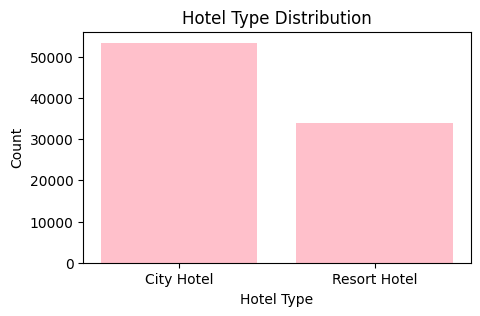

In [ ]:
df = data['hotel'].value_counts()

x = df.index
y = df.values

plt.figure(figsize=(5,3))

plt.bar(x,y,color = 'pink')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.title('Hotel Type Distribution')
plt.show()

#### 2. Booking Cancellation rate

In [ ]:
cancellation_rate = data.groupby('is_canceled')['is_canceled'].count()

In [ ]:
cancellation_rate_pct = data['is_canceled'].value_counts(normalize=True).mul(100).round(2)

In [ ]:
cancellation_rate_pct

,proportion
is_canceled,
0,72.5
1,27.5


Text(0.5, 1.0, 'Booking Cancellation rate')

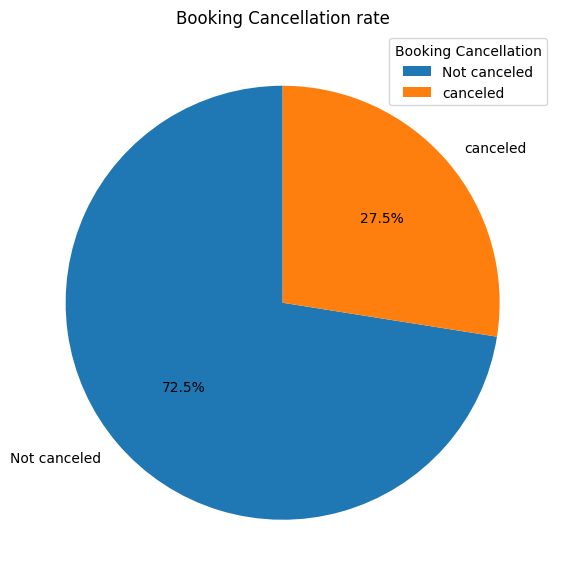

In [ ]:
label = ['Not canceled','canceled']
values = cancellation_rate_pct.values

plt.figure(figsize=(7,9))

plt.pie(values,labels=label,autopct='%1.1f%%',startangle=90)
plt.legend(label,title='Booking Cancellation')
plt.title('Booking Cancellation rate')

#### 3.Monthly booking

In [ ]:
monthly_booking = data.groupby('arrival_date_month')['arrival_date_month'].count()

In [ ]:
monthly_booking

,arrival_date_month
arrival_date_month,
April,7905
August,11257
December,5128
February,6091
January,4691
July,10055
June,7765
March,7510
May,8354


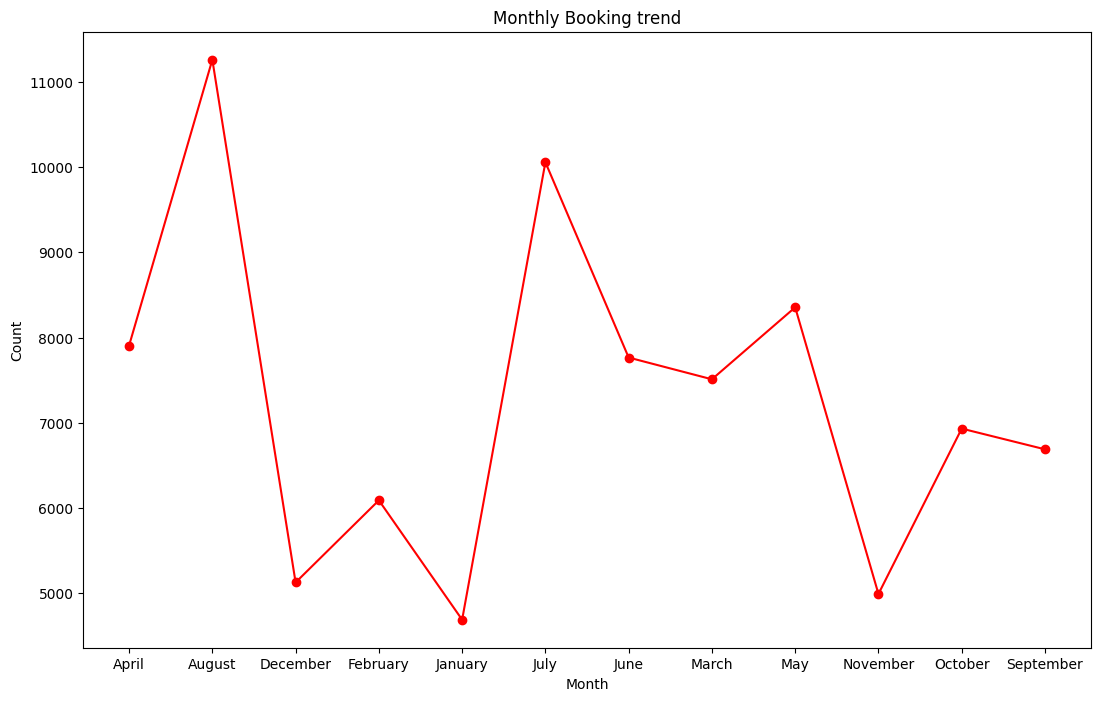

In [ ]:
x = monthly_booking.index
y = monthly_booking.values

plt.figure(figsize=(13,8))

plt.plot(x,y,marker = 'o',color='red')
plt.title('Monthly Booking trend')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

#### 4.Lead Time Distribution

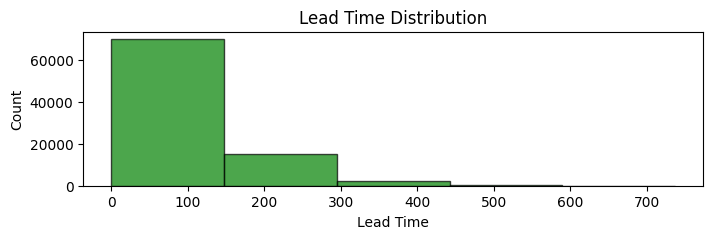

In [ ]:
df = data['lead_time']

plt.figure(figsize=(8,2))

plt.hist(df,bins=5,color='green',edgecolor='black',alpha=0.7)
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time')
plt.ylabel('Count')
plt.show()

#### 5.Average Stay Length

In [ ]:
df1 = data.groupby('hotel').describe()[['Total_stay','stays_in_week_nights','stays_in_weekend_nights']]

In [ ]:
df1

Total_stay                                                \
                  count      mean       std  min  25%  50%  75%   max   
hotel                                                                   
City Hotel      53426.0  3.146689  2.089506  0.0  2.0  3.0  4.0  57.0   
Resort Hotel    33944.0  4.393914  3.440249  0.0  2.0  4.0  7.0  69.0   

             stays_in_week_nights            ...             \
                            count      mean  ...  75%   max   
hotel                                        ...              
City Hotel                53426.0  2.274511  ...  3.0  41.0   
Resort Hotel              33944.0  3.178706  ...  5.0  50.0   

             stays_in_weekend_nights                                          \
                               count      mean       std  min  25%  50%  75%   
hotel                                                                          
City Hotel                   53426.0  0.872178  0.913765  0.0  0.0  1.0  2.0   
Resort Hotel                 33944.0  1.215207  1.164072  0.0  0.0  1.0  2.0   

                    
               max  
hotel               
City Hotel    16.0  
Resort Hotel  19.0  

[2 rows x 24 columns]

#### 6.Country-wise Booking count

In [ ]:
df2 = data['country'].value_counts().sort_values(ascending=False).head(10)

In [ ]:
df2

,count
country,
PRT,27882
GBR,10432
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


#### 7. Customer-segment Analysis

Text(0.5, 1.0, 'Customer-segment Analysis')

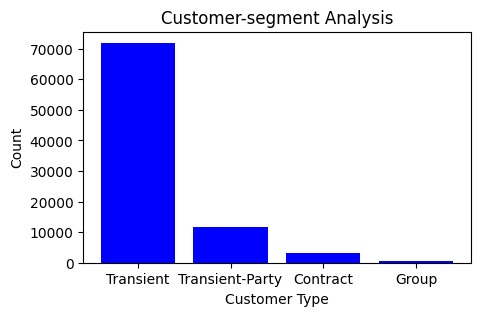

In [ ]:
df3 = data['customer_type'].value_counts()

x = df3.index
y = df3.values

plt.figure(figsize=(5,3))

plt.bar(x,y,color = 'blue')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.title('Customer-segment Analysis')

#### 8.Top booking rooms

In [ ]:
df4 = data.groupby('assigned_room_type').size().sort_values(ascending=False)

print(df4)

assigned_room_type
A    46301
D    22422
E     7193
F     3625
G     2498
C     2165
B     1820
H      706
I      357
K      276
P        6
L        1
dtype: int64


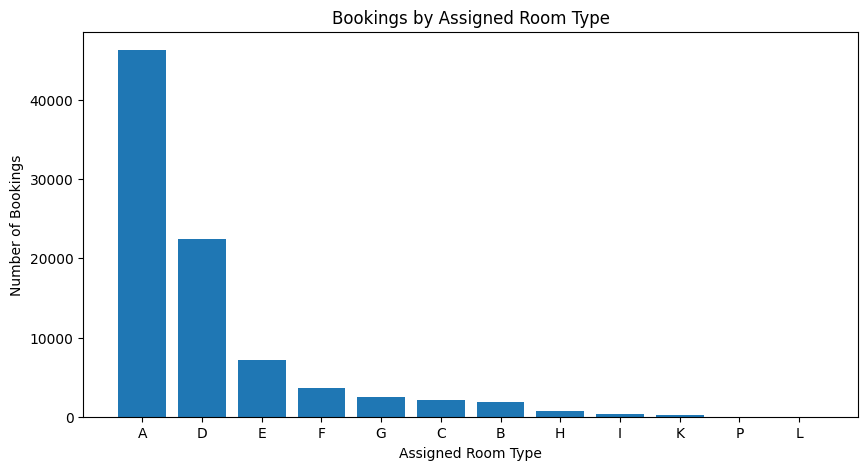

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(df4.index, df4.values)

plt.xlabel('Assigned Room Type')
plt.ylabel('Number of Bookings')
plt.title('Bookings by Assigned Room Type')

plt.show()

#### 9. Total revenve per customer type

In [ ]:
revenue = data.groupby('customer_type')['adr'].sum().sort_values(ascending=False)

In [ ]:
revenue

,adr
customer_type,
Transient,7927307.83
Transient-Party,1027179.22
Contract,291151.78
Group,45892.90


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

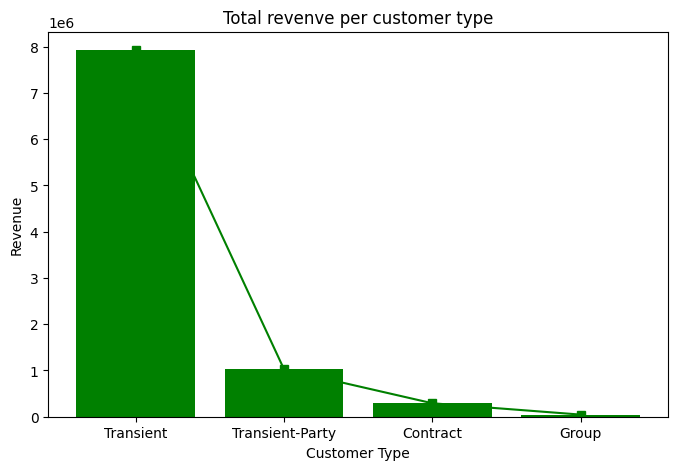

In [ ]:
x = revenue.index
y = revenue.values

plt.figure(figsize=(8,5))

plt.plot(x,y,marker='s',color='green')
plt.bar(x,y,color = 'green')
plt.xlabel('Customer Type')
plt.ylabel('Revenue')
plt.title('Total revenve per customer type')
plt

#### 10. ADR(Average Daily Rate)

In [ ]:
data['adr'].describe()

,adr
count,87370.000000
mean,106.346935
std,55.004259
min,-6.380000
25%,72.000000
50%,98.100000
75%,134.000000
max,5400.000000


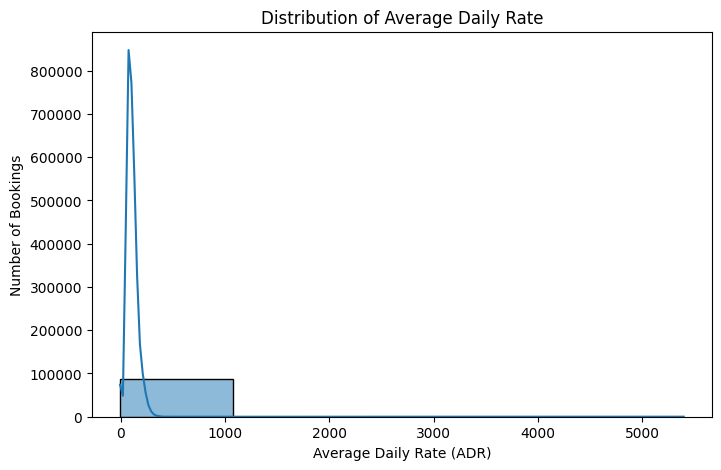

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(data=data, x='adr', bins=5, kde=True)

plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('Number of Bookings')
plt.title('Distribution of Average Daily Rate')

plt.show()